In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
folder_path = '/content/drive/MyDrive/CAE_dataset_training/dataset_tutup_training'

In [ ]:
def load_data(folder_path, img_size=64):
    data = []
    for filename in os.listdir(folder_path):
        path = os.path.join(folder_path, filename)
        img = load_img(path, target_size=(img_size, img_size)) #load img
        img = img_to_array(img) #convert array
        img = img / 255.0 #normalisasi 0-1
        data.append(img)
    return np.array(data)

In [ ]:
#split data
X = load_data(folder_path)
X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)

print(f'Data Training: {len(X_train)} | Data Validasi: {len(X_val)}')

Data Training: 560 | Data Validasi: 141


In [ ]:
#arsitektur untuk Tutup Botol (64x64)

input_img = layers.Input(shape=(64, 64, 3))

# ENCODER
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x) # hasil: 32x32x64

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x) # hasil: 16x16x32

x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x) # hasil Latent: 8x8x16

# latent 8x8x16 = 1.024 angka

# DECODER
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x) # hasil: 16x16x16

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x) # hasil: 32x32x32

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x) # hasil: 64x64x64

decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

# model
autoencoder = models.Model(input_img, decoded)

# optimizer, learning rate
autoencoder.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,067 (203.39 KB)

 Trainable params: 52,067 (203.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#early stop
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

#training
history = autoencoder.fit(
    X_train, X_train,
    epochs=250,
    batch_size=32,
    shuffle=True,
    validation_data=(X_val, X_val),
    callbacks=[early_stop]
)

Epoch 1/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 301ms/step - loss: 0.0821 - val_loss: 0.0492
Epoch 2/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0280 - val_loss: 0.0158
Epoch 3/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0130 - val_loss: 0.0108
Epoch 4/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0100 - val_loss: 0.0088
Epoch 5/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0083 - val_loss: 0.0076
Epoch 6/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0075 - val_loss: 0.0071
Epoch 7/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0069 - val_loss: 0.0064
Epoch 8/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0064 - val_loss: 0.0061
Epoch 9/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0061 - val_loss: 0.0059
Epoch 10/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0059 - val_loss: 0.0058
Epoch 11/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0058 - val_loss: 0.0056
Epoch 12/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/st

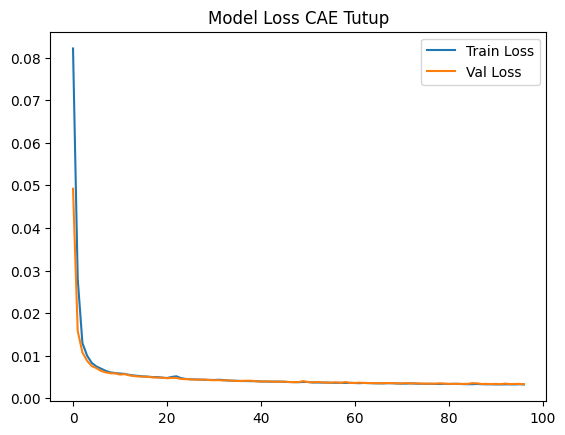

In [ ]:
#tampilkan grafik loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss CAE Tutup')
plt.legend()
plt.savefig('grafik_loss_cae.png')
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step


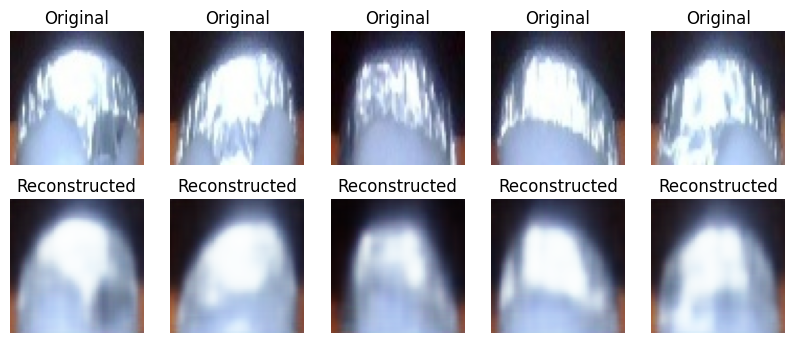

In [ ]:
#testing
#ambil gambar dari data validasi
decoded_imgs = autoencoder.predict(X_val)

n = 5 #tampil 5 contoh
plt.figure(figsize=(10,4))
for i in range(n):
  #gambar asli
  ax = plt.subplot(2, n, i+1)
  plt.imshow(X_val[i])
  plt.title('Original')
  plt.axis('off')

  #gambar rekonstruksi
  ax = plt.subplot(2, n, i + 1 + n)
  plt.imshow(decoded_imgs[i])
  plt.title('Reconstructed')
  plt.axis('off')

plt.show()

In [ ]:
print(autoencoder.input_shape)

(None, 64, 64, 3)


In [ ]:
#save model
autoencoder.save("cae_model_tutup.keras")

In [ ]:
#download model
from google.colab import files

files.download('cae_model_tutup.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>